In [119]:
!pip install segmentation-models-pytorch

In [1]:
import os
import pandas as pd
from torchvision.io import read_image
import torch
import torch.nn as nn
from torch.utils.data import Dataset
import torchvision.transforms as transforms
from PIL import Image
from torch.utils.data import DataLoader
import torchvision.models as models
import segmentation_models_pytorch as smp
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import cv2
from pathlib import Path
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

Analyse of the dataset

In [2]:
# Load the file containing images labels

label_train = pd.read_csv('/Users/laurageneaulibourne/Downloads/S4/computer_vision/exam/datasets/dataset_retina/Fundus_Image_Vessel_dataset/train/Quality_Assessment_train.csv', sep=';')
label_test = pd.read_csv('/Users/laurageneaulibourne/Downloads/S4/computer_vision/exam/datasets/dataset_retina/Fundus_Image_Vessel_dataset/test/Quality_Assessment_test.csv', sep=';')


In [3]:
# Change the order of columns of label_train and label_test
new_order = ['Number', 'Disease', 'IC', 'Blur', 'LC']

mapping = {'A': 0, 'D': 1, 'G': 2, 'N': 3}
reverse = {0: 'A', 1: 'D', 2: 'G', 3: 'N'}

label_train = label_train[new_order]
label_train['Disease'] = label_train['Disease'].map(mapping)


label_train.to_csv('/Users/laurageneaulibourne/Downloads/S4/computer_vision/exam/datasets/dataset_retina/Fundus_Image_Vessel_dataset/train/Quality_Assessment_train_clean.csv', index=False, sep=';')

label_test = label_test[new_order]
label_test['Disease'] = label_test['Disease'].map(mapping)
label_test.to_csv('/Users/laurageneaulibourne/Downloads/S4/computer_vision/exam/datasets/dataset_retina/Fundus_Image_Vessel_dataset/test/Quality_Assessment_test_clean.csv', index=False, sep=';')

In [5]:
label_train = pd.read_csv('/Users/laurageneaulibourne/Downloads/S4/computer_vision/exam/datasets/dataset_retina/Fundus_Image_Vessel_dataset/train/Quality_Assessment_train_clean.csv', sep=';')
label_test = pd.read_csv('/Users/laurageneaulibourne/Downloads/S4/computer_vision/exam/datasets/dataset_retina/Fundus_Image_Vessel_dataset/test/Quality_Assessment_test_clean.csv', sep=';')

In [4]:
train_size = len(label_train)
test_size = len(label_test)

print("Repartition % of diseases in train and test set :")
print(label_train['Disease'].value_counts() *100 / train_size )
print(label_test['Disease'].value_counts() *100 / test_size )

Repartition % of diseases in train and test set :
Disease
0    25.0
1    25.0
2    25.0
3    25.0
Name: count, dtype: float64
Disease
0    25.0
1    25.0
2    25.0
3    25.0
Name: count, dtype: float64


In [5]:
print("Repartition % of Illumination Color in train and test set :")
print(label_train['IC'].value_counts() *100 / train_size )
print(label_test['IC'].value_counts() *100 / test_size )


print("Repartition % of Blur in train and test set :")
print(label_train['Blur'].value_counts() *100 / train_size )
print(label_test['Blur'].value_counts() *100 / test_size )


print("Repartition % of Low Contrast in train and test set :")
print(label_train['LC'].value_counts() *100 / train_size )
print(label_test['LC'].value_counts() *100 / test_size )

print("\n")

print("Repartition % of Low Contrast or blurred images in train :")
condition = ((label_train["Blur"] == 0) | (label_train["LC"] == 0)) & (label_train["IC"] == 1)
percentage = condition.sum() * 100 / train_size
print(percentage)

print("Repartition % of Low Contrast or blurred images in test :")
condition = ((label_test["Blur"] == 0) | (label_test["LC"] == 0)) & (label_test["IC"] == 1)
percentage = condition.sum() * 100 / test_size
print(percentage)


Repartition % of Illumination Color in train and test set :
IC
1    82.666667
0    17.333333
Name: count, dtype: float64
IC
1    74.0
0    26.0
Name: count, dtype: float64
Repartition % of Blur in train and test set :
Blur
1    85.0
0    15.0
Name: count, dtype: float64
Blur
1    79.5
0    20.5
Name: count, dtype: float64
Repartition % of Low Contrast in train and test set :
LC
1    96.666667
0     3.333333
Name: count, dtype: float64
LC
1    92.5
0     7.5
Name: count, dtype: float64


Repartition % of Low Contrast or blurred images in train :
6.166666666666667
Repartition % of Low Contrast or blurred images in test :
7.5


In [7]:
class CustomImageDataset(Dataset):
    """ Create a personalized Dataset class."""

    def __init__(self, annotations_file, img_dir, mask_dir, img_transform=None, mask_transform=None):
        """ Set up paths and images transformations.

        Args :
        annotation_file : pandas data frame containing images labels.
        img_dir : path of the directory where images are stored.
        mask_dir : path of the directory where masks are stored.
        img_transform : transformations that will be applied to images.
        mask_transform : transformations that will be applied to masks. """

        self.img_labels = annotations_file 
        self.img_dir = img_dir
        self.mask_dir = mask_dir 
        self.img_transform = img_transform
        self.mask_transform = mask_transform

    def __len__(self):
        """ Return the number of samples in the dataset."""

        return len(self.img_labels)
   
    def __getitem__(self, idx):
        """ For a given index, it returns the sample (image, mask, label) associated to it.
        Args : 
        idx : index of a sample.

        Returns:
        image : tensor of shape [C,H,W].
        mask : tensor of shape [1, H, W].
        label : tensor of shape [1,4] containing information about the image.
        """
        
        # Reconstruction of the image's name
        name_image = str(self.img_labels.iloc[idx, 0]) + '_' + reverse[int(self.img_labels.iloc[idx, 1])]+ '.png'
        
        # Reconstruction of the image's path
        img_path = os.path.join(self.img_dir, name_image)
        # Reconstruction of the mask's path
        mask_path = os.path.join(self.mask_dir, name_image)
        
        # Open the image so it can be transformed
        image = Image.open(img_path).convert('RGB') #some images have 4 channels 
        # Open the mask so it can be transformed
        mask = Image.open(mask_path).convert('L')
        # Retrieve information about the image
        label = torch.tensor(self.img_labels.iloc[idx, 1:].values.astype('float32'), dtype=torch.float32)
        
        # Apply transformations on the image
        if self.img_transform:
            image = self.img_transform(image)

        # Apply transformations on the mask
        if self.mask_transform:
            mask = self.mask_transform(mask)
   
        return image, mask, label
    

In [8]:

# List of transformations that will be applied to images and masks
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

mask_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor()  
])


path_dataset ="/Users/laurageneaulibourne/Downloads/S4/computer_vision/exam/datasets/dataset_retina/Fundus_Image_Vessel_dataset"

fundus_dataset_train = CustomImageDataset(annotations_file= label_train, img_dir = path_dataset + "/train/imgs", mask_dir = path_dataset + "/train/masks", img_transform=transform, mask_transform=mask_transform)
fundus_dataset_test = CustomImageDataset(annotations_file= label_test, img_dir = path_dataset + "/test/imgs", mask_dir = path_dataset + "/test/masks", img_transform=transform, mask_transform=mask_transform)

train_dataloader = DataLoader(fundus_dataset_train, batch_size=64, shuffle=True)
test_dataloader= DataLoader(fundus_dataset_test, batch_size=64, shuffle=True)

# Train

In [21]:
def train_loop_basic(dataloader, model, loss_seg, loss_class, optimizer, num_epochs, device, alpha, beta):

    size = len(dataloader.dataset)  
    model = model.to(device)
    model.train()

    # This list will contain lists. Each of them will contain an image, the associated mask (ground truth) and the predicted mask
    list_imgs_each_epoch = []

    k = 0
    
    for epoch in range(num_epochs):
        epoch_loss = 0.0
        epoch_loss_class = 0.0
        epoch_loss_seg = 0.0
        
        # This dictionary will contain the number of predictions for each class ({A, D, G, N}_tot)
        # and the number of good predictions done for each class ({A, D, G, N}_true)
        dic_acc_disease = {"A_true": 0,"A_tot": 0,  "D_true": 0, "D_tot" : 0,  "G_true": 0, "G_tot" : 0, "N_true": 0, "N_tot": 0}
        
        # This list will contain the image, the mask (ground truth) and the predicted mask of the first image of the first batch of the current epoch
        L = []
        

        for image, mask, label in dataloader:
            
            # Put images, masks and labels of the batch in the same device
            image= image.to(device)
            mask= mask.to(device)
            label= label.to(device)
           
            
            # Set gradient to zero
            optimizer.zero_grad()

            # Apply the model to each image of the batch.
            # pred_segm : tensor of shape [B,1,H,W]
            # B : batch size, 1: number of channels, H: height of the mask, W: width of the mask
            # pred_segm contains raw logits
            # pred_class : tensor of shape [B, N]
            # N : number of classes
            # pred_class contains raw logits
            pred_segm, pred_class = model(image)


            # For each image, chose the class with the higher score
            pred_class_indices = pred_class.argmax(dim=1)
            
            batch_loss_class = 0
            batch_loss_seg = 0

            # Count the number of predictions and the number of good prediction for each class
            for i in range (len(label)):
                label_name = reverse[label[i,0].item()]
                dic_acc_disease[label_name + "_tot"] += 1 
                if label[i,0].item() == pred_class_indices[i].item() :
                   dic_acc_disease[label_name + "_true"] += 1
            

            batch_loss_seg = loss_seg(pred_segm, mask)
            batch_loss_class = loss_class(pred_class, label[:,0].long())
                    
            # Apply a penalty alpha for the loss associated to the classification and betafor the one associated to segmentation
            batch_loss_class = alpha * batch_loss_class
            epoch_loss_class += batch_loss_class.item()
            batch_loss_seg = beta * batch_loss_seg
            epoch_loss_seg += batch_loss_seg.item()
           
            batch_loss = (batch_loss_class + batch_loss_seg) / len(label) 
            
            # Backpropagation
            batch_loss.backward()
            optimizer.step()
        
            # Retrieve the first image of the first batch and its mask 
            if k == 1: # We dont't want to store anything of the first batch of the first epoch because they are not representative of the model's performance
                L.append(image[0].detach().cpu().permute(1,2,0).numpy())  
                L.append(mask[0].detach().cpu().permute(1,2,0).numpy())
                L.append(pred_segm[0].detach())
                k = 2

        epoch_loss_class /= size
        epoch_loss_seg /= size
    
        epoch_loss = epoch_loss_class + epoch_loss_seg


        list_imgs_each_epoch.append(L)
        
        k = 1 
        
        print(f'Epoch {epoch+1}/{num_epochs}, Total Loss: {epoch_loss},Classification Loss: {epoch_loss_class}, Total Segmentation Loss: {epoch_loss_seg},Accuracy diseases: A : {dic_acc_disease["A_true"] *100 / dic_acc_disease["A_tot"]} %, D :{dic_acc_disease["D_true"] *100 / dic_acc_disease["D_tot"]} %, G :{dic_acc_disease["G_true"] *100 / dic_acc_disease["G_tot"]} %, N :{dic_acc_disease["N_true"] *100 / dic_acc_disease["N_tot"]} %)')

    return list_imgs_each_epoch
    


# Test 

In [22]:
def test_loop_basic(dataloader, model, loss_seg, loss_class, device, alpha, beta):

    size = len(dataloader.dataset)  
    model = model.to(device)
    model.eval()

    
    test_loss = 0.0
    test_loss_seg = 0.0
    test_loss_class = 0.0

    
    # This dictionary will contain the number of predictions for each class ({A, D, G, N}_tot)
    # and the number of good predictions made for each class ({A, D, G, N}_true)
    dic_acc_disease = {"A_true": 0,"A_tot": 0,  "D_true": 0, "D_tot" : 0,  "G_true": 0, "G_tot" : 0, "N_true": 0, "N_tot": 0}
    
    # Store predicted labels for the confusion matrix
    all_pred = []
    # Store true labels for the confusion matrix
    all_labels = []
    # This list will contain the image, the mask (ground truth) and the predicted mask of the first image of the first batch of the current epoch
    L = []

    with torch.no_grad():
        for image, mask, label in dataloader:
            
            # Put images, masks and labels of the current batch in the same device
            image= image.to(device)
            mask= mask.to(device)
            label= label.to(device)
        
            # Apply the model on each image of the batch
            # pred_segm : tensor of shape [B, 1, H, W]. It contains raw logits.
            # pred_clss : tensor of shape [B, N]. It contains raw logits
            pred_segm, pred_class = model(image)
            # For each image, chose the class that has the highest score
            pred_class_indices = pred_class.argmax(dim=1)

            
            # Store the predicted label of each image of the batch
            all_pred.extend(pred_class_indices.cpu().numpy())
            # Store the true label of each image of the batch
            all_labels.extend(label[:,0].cpu().numpy())

            # Count the number of predictions and the number of good predictions made for each class
            for i in range (len(label)):
                label_name = reverse[label[i,0].item()]
                dic_acc_disease[label_name + "_tot"] += 1 
                if label[i,0].item() == pred_class_indices[i].item() :
                   dic_acc_disease[label_name + "_true"] += 1
            
            # Apply a penalty to the loss segmentation and to the loss classification
            test_loss_seg += beta * loss_seg(pred_segm, mask)
            test_loss_class += alpha * loss_class(pred_class, label[:,0].long())

            # Retrieve the first image of the first batch and its mask
            L.append([image[0].detach().cpu().permute(1,2,0).numpy(), mask[0].detach().permute(1,2,0).cpu().numpy(), pred_segm[0].detach()])    
        
        test_loss_seg /= size
        test_loss_class /= size
        test_loss = test_loss_class + test_loss_seg

        
        
        print(f' Total Loss: {test_loss},Classification Loss: {test_loss_class}, Total Segmentation Loss: {test_loss_seg},Accuracy diseases: A : {dic_acc_disease["A_true"] *100 / dic_acc_disease["A_tot"]} %, D :{dic_acc_disease["D_true"] *100 / dic_acc_disease["D_tot"]} %, G :{dic_acc_disease["G_true"] *100 / dic_acc_disease["G_tot"]} %, N :{dic_acc_disease["N_true"] *100 / dic_acc_disease["N_tot"]} %)')
    return all_pred, all_labels, L

In [26]:
def decode_segmap(img):
  """ This function displays the segmentation mask.
  Args : 
  img : numpy array containing ones (for the optic nerve) and zeros (for the background)
  """
  label_colors = np.array([(0,0,0), (255,255,255)])

  r = np.zeros_like(img).astype(np.uint8)
  g = np.zeros_like(img).astype(np.uint8)
  b = np.zeros_like(img).astype(np.uint8)

  for i in range(2):
    idx = img == i
    r[idx] = label_colors[i,0]
    g[idx] = label_colors[i,1]
    b[idx] = label_colors[i,2]

  return np.stack([r,g,b], axis = 2)



def imgs_per_epoch(list_imgs, save_dir = None, train = True):
  """ This function displays images contained in the input list.
  Args :
  list_imgs : list containing an original image (numpy array), the corresponding mask - ground truth (numpy array)
  and the predicted mask (containing raw logits)
  save_dir : path of the folder where we want to store images.
  train : boolean that enables to know if images are from the training set or the test set
  """
  if save_dir:
    os.makedirs(save_dir, exist_ok = True)


  count = 1
  for l in list_imgs:
    count += 1

  if train:
    print(f"Epoch {count}")

  img = l[0]
  plt.imshow(img)
  plt.title("Fundus")
  plt.axis("off")
  if save_dir:
    plt.savefig(f"{save_dir}/epoch_{count}_img.png")
  plt.show()

  mask = l[1]
  plt.imshow(mask, cmap = "gray", vmin = 0, vmax = 1)
  plt.title("Mask - ground truth")
  plt.axis("off")
  if save_dir:
    plt.savefig(f"{save_dir}/epoch_{count}_mask.png")
  plt.show()

  predicted_mask = l[2].squeeze()
  #print(predicted_mask.shape)
  predicted_mask = torch.sigmoid(predicted_mask)
  predicted_mask = ( predicted_mask > 0.5).int()
  Inp_mask_pred = decode_segmap(predicted_mask.cpu().squeeze(0).numpy())
  plt.imshow(Inp_mask_pred)
  plt.title("Mask - prediction")
  plt.axis("off")
  if save_dir:
    plt.savefig(f"{save_dir}/epoch_{count}_pred_mask.png")
  plt.show()

# Models 

In [29]:

# segmentation :
model_segmentation = smp.Unet(
    encoder_name="resnet34",        
    encoder_weights="imagenet",     
    in_channels=3,                 
    classes=1,                      
)

# global classification  :
model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
    aux_params=dict(
        pooling='avg',             
        dropout=0.4,               
        classes=4, # A,D, G, N                 
    )
)



In [30]:
model_segmentation2 = smp.Unet(
    encoder_name="resnet18",        
    encoder_weights="imagenet",     
    in_channels=3,                 
    classes=1,                      
)

# global classification  :
model2 = smp.Unet(
    encoder_name="resnet18",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
    aux_params=dict(
        pooling='avg',             
        dropout=0.4,               
        classes=4, # A,D, G, N           
    )
)

In [ ]:
loss_seg= torch.nn.BCEWithLogitsLoss()  
loss_class = nn.CrossEntropyLoss()
loss_seg_faster= torch.nn.BCEWithLogitsLoss(reduction='none')
loss_class_faster = nn.CrossEntropyLoss(reduction='none')
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
optimizer2 = torch.optim.Adam(model2.parameters(), lr=0.001)
num_epochs = 10
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
alpha = 1
beta = 1
gama = 2


### Train and test with train_loop_basic/test_loop_basic without data augmentation using Unet and resnet18

In [ ]:
imgs_epoch_basic_1 = train_loop_basic(train_dataloader, model2, loss_seg, loss_class, optimizer2, num_epochs, device, alpha, beta)

In [ ]:
all_pred, all_labels, img_test_basic = test_loop_basic(test_dataloader, model2, loss_seg, loss_class, device, alpha, beta)

 Total Loss: 0.024850867688655853,Classification Loss: 0.021782144904136658, Total Segmentation Loss: 0.00306872371584177,Accuracy diseases: A : 74.0 %, D :94.0 %, G :74.0 %, N :52.0 %)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.129035].


Epoch 10


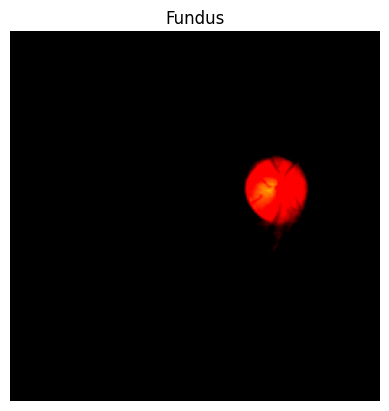

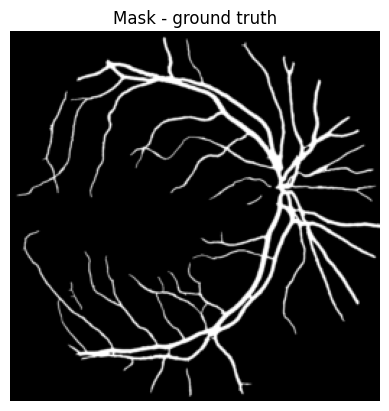

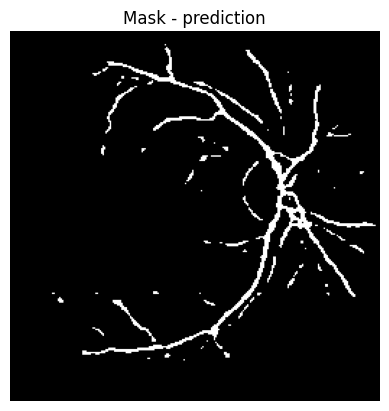

In [ ]:
imgs_per_epoch(imgs_epoch_basic_1[1:], "/Users/laurageneaulibourne/Downloads/S4/computer_vision/exam/train_basic_18")

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.1007793..2.2489083].


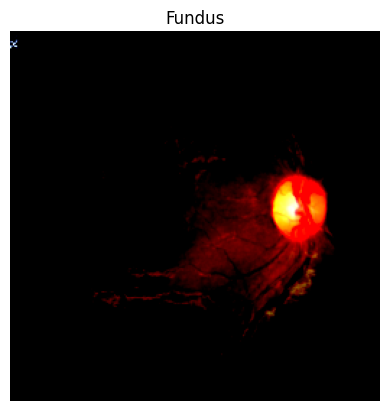

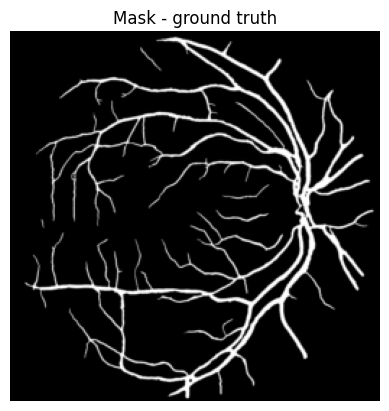

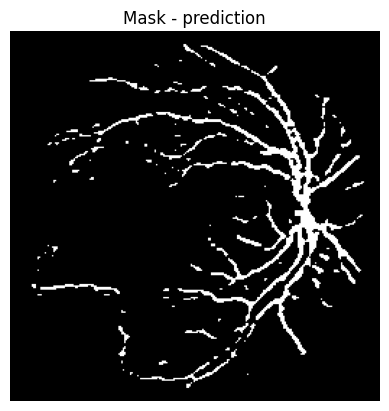

In [ ]:
imgs_per_epoch(img_test_basic, "/Users/laurageneaulibourne/Downloads/S4/computer_vision/exam/test_basic_18", False)

##### Confusion matrix

In [ ]:
cm = confusion_matrix(all_labels, all_pred)
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['A', 'D', 'G', 'N'])
cm_display.plot()
plt.savefig("/Users/laurageneaulibourne/Downloads/S4/computer_vision/exam/conf_mat_basic_18.png")
plt.plot()

### Train and test with train_loop_basic/test_loop_basic without data augmentation using Unet and resnet34

In [ ]:
imgs_epoch_basic_2 = train_loop_basic(train_dataloader, model, loss_seg, loss_class, optimizer, num_epochs, device, alpha, beta)

Epoch 1/10, Total Loss: 0.03941770027081172,Classification Loss: 0.02717600703239441, Total Segmentation Loss: 0.012241693238417308,Accuracy diseases: A : 46.666666666666664 %, D :46.0 %, G :58.0 %, N :70.0 %)
Epoch 2/10, Total Loss: 0.02082680175701777,Classification Loss: 0.013059225330750147, Total Segmentation Loss: 0.007767576426267624,Accuracy diseases: A : 72.66666666666667 %, D :40.0 %, G :78.0 %, N :88.66666666666667 %)
Epoch 3/10, Total Loss: 0.015448434402545293,Classification Loss: 0.009623773992061616, Total Segmentation Loss: 0.005824660410483678,Accuracy diseases: A : 74.66666666666667 %, D :58.0 %, G :84.0 %, N :94.66666666666667 %)
Epoch 4/10, Total Loss: 0.013225469291210174,Classification Loss: 0.008593994428714117, Total Segmentation Loss: 0.004631474862496058,Accuracy diseases: A : 72.0 %, D :69.33333333333333 %, G :89.33333333333333 %, N :94.0 %)
Epoch 5/10, Total Loss: 0.011644644563396773,Classification Loss: 0.007690722544987996, Total Segmentation Loss: 0.0039

In [ ]:
all_pred2, all_labels2, img_test_basic_2 = test_loop_basic(test_dataloader, model, loss_seg, loss_class, device, alpha, beta)

 Total Loss: 0.029310520738363266,Classification Loss: 0.02601119689643383, Total Segmentation Loss: 0.003299324307590723,Accuracy diseases: A : 44.0 %, D :64.0 %, G :96.0 %, N :58.0 %)
